# Data Visualization

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path
from collections import namedtuple

dataset = namedtuple("dataset", ["reviews", "metadata", "ratings"])

## 1. Load Data

- ```REVIEW_PATH```: The file path to the JSON file containing user book review information.

- ```METADATA_PATH```: The file path to the JSON file containing book metadata.

- ```RATINGS_BOOK```: The file path to the CSV file without a header. These datasets do not include metadata or review text, but only pairs of (user, item, rating, timestamp). Therefore, they are suitable for use with the MyMediaLite package (or similar packages).

In [18]:
REVIEWS_PATH = "./data/reviews_Books_5_sample.json"
METADATA_PATH = "./data/meta_Books_sample.json"
RATINGS_PATH = "./data/ratings_Books_sample.csv"

def load_data(reviews_path: str, metadata_path: str, ratings_path: str) -> dataset:
    reviews_df = pd.read_json(reviews_path, lines=True)
    metadata_df = pd.read_json(metadata_path, lines=True)
    ratings_df = pd.read_csv(
        RATINGS_PATH,
        header=None,
        names=["reviewerID", "asin", "overall", "unixReviewTime"]
    )
    return dataset(reviews=reviews_df, metadata=metadata_df, ratings=ratings_df)

dataset = load_data(REVIEWS_PATH, METADATA_PATH, RATINGS_PATH)
if dataset.reviews.empty or dataset.metadata.empty or dataset.ratings.empty:
    raise ValueError("One or more datasets are empty. Please check the data files.")
else:
    print("All datasets loaded successfully.")

All datasets loaded successfully.


## 2. Data Overview

### 2.1 Data strucure

In [33]:
def get_detailed_dtype(series: pd.Series) -> str:
    """Return a more descriptive data type for a pandas Series."""

    if series.dtype != "object":
        return str(series.dtype)

    # Ignore null values when determining the underlying Python types
    non_null = series.dropna()

    if non_null.empty:
        return "object (empty)"

    types = Counter(type(value).__name__ for value in non_null)

    # One consistent Python type
    if len(types) == 1:
        return f"object ({next(iter(types))})"

    # Multiple Python types
    type_details = ", ".join(
        f"{type_name}: {count}"
        for type_name, count in types.items()
    )

    return f"object (mixed: {type_details})"


def get_info_data(df: pd.DataFrame) -> dict:
    return {
        "num_records": len(df),
        "num_columns": len(df.columns),
        "columns": [
            {
                "name": column,
                "data_type": get_detailed_dtype(df[column]),
                "non_null_count": int(df[column].notna().sum()),
                "null_count": int(df[column].isna().sum()),
            }
            for column in df.columns
        ],
    }


def print_info_data(df: pd.DataFrame, name: str) -> None:
    info = get_info_data(df)

    print("\n" + "=" * 70)
    print(f"DataFrame: {name}")
    print("=" * 70)

    print(f"Records : {info['num_records']:,}")
    print(f"Columns : {info['num_columns']}")
    print("-" * 70)

    print(
        f"{'Column':<25} "
        f"{'Data Type':<25} "
        f"{'Non-Null':>10} "
        f"{'Null':>10}"
    )
    print("-" * 70)

    for column in info["columns"]:
        print(
            f"{column['name']:<25} "
            f"{column['data_type']:<25} "
            f"{column['non_null_count']:>10,} "
            f"{column['null_count']:>10,}"
        )

    print("=" * 70)
    
def print_sample_data(df: pd.DataFrame, name: str, num_samples: int = 1) -> None:
    print("\n" + "=" * 70)
    print(f"Sample Data from DataFrame: {name}")
    print("=" * 70)
    print(df.head(num_samples))
    print("=" * 70)

print_info_data(df = dataset.reviews, name="Reviews Books")
print_info_data(df=dataset.metadata, name="Meta Books")
print_info_data(df=dataset.ratings, name="Ratings Books")
print_sample_data(df=dataset.reviews, name="Reviews Books")
print_sample_data(df=dataset.metadata, name="Meta Books")
print_sample_data(df=dataset.ratings, name="Ratings Books")


DataFrame: Reviews Books
Records : 1,000
Columns : 9
----------------------------------------------------------------------
Column                    Data Type                   Non-Null       Null
----------------------------------------------------------------------
reviewerID                str                            1,000          0
asin                      str                            1,000          0
reviewerName              str                            1,000          0
helpful                   object (list)                  1,000          0
reviewText                str                            1,000          0
overall                   int64                          1,000          0
summary                   str                            1,000          0
unixReviewTime            int64                          1,000          0
reviewTime                str                            1,000          0

DataFrame: Meta Books
Records : 1,000
Columns : 18
------------

### 2.2. Relationship

In [25]:
def is_primary_key(df: pd.DataFrame, columns: list) -> bool:
    if not set(columns).issubset(df.columns):
        missing_cols = set(columns) - set(df.columns)
        print(f"The columns do not exist in the DataFrame.: {list(missing_cols)}")
        return False
    if df[columns].isnull().any().any():
        return False
    is_unique = not df.duplicated(subset=columns).any()
    return is_unique

def print_primary_key_check(df: pd.DataFrame, columns: list, name: str) -> None:
    if is_primary_key(df, columns):
        print(f"The columns {columns} form a primary key in {name}.")
    else:
        print(f"The columns {columns} do not form a primary key in {name}.")

def cardinality(left_df, left_keys, right_df, right_keys):
    if isinstance(left_keys, str):
        left_keys = [left_keys]
    if isinstance(right_keys, str):
        right_keys = [right_keys]
    if len(left_keys) != len(right_keys):
        raise ValueError("The number of left_keys and right_keys must be equal.")
    missing_left = [col for col in left_keys if col not in left_df.columns]
    missing_right = [col for col in right_keys if col not in right_df.columns]
    if missing_left:
        raise ValueError(f"Columns do not exist in left_df: {missing_left}")
    if missing_right:
        raise ValueError(f"Columns do not exist in right_df: {missing_right}")
    left_unique_count = (
        left_df[left_keys]
        .drop_duplicates()
        .shape[0]
    )
    right_unique_count = (
        right_df[right_keys]
        .drop_duplicates()
        .shape[0]
    )
    left_unique = left_unique_count == len(left_df)
    right_unique = right_unique_count == len(right_df)
    if left_unique and right_unique:
        relationship = "1 : 1"
    elif left_unique and not right_unique:
        relationship = "1 : N"
    elif not left_unique and right_unique:
        relationship = "N : 1"
    else:
        relationship = "N : N"

    return relationship

print_primary_key_check(dataset.reviews, ["reviewerID", "asin"], "Reviews Books")
print_primary_key_check(dataset.metadata, ["asin"], "Metadata Books")
print_primary_key_check(dataset.ratings, ["reviewerID", "asin"], "Ratings Books")

print("\nCardinality between metadata and reviews:")
car_meta_review = cardinality(dataset.metadata, 'asin', dataset.reviews, 'asin')
print(f"metadata (asin) -> reviews (asin): {car_meta_review}")
    
print("\nCardinality between reviews and ratings:")
car_re_ra_reviewerID = cardinality(dataset.reviews, 'reviewerID', dataset.ratings, 'reviewerID')
car_re_ra_asin = cardinality(dataset.reviews, 'asin', dataset.ratings, 'asin')
car_re_ra_composite = cardinality(dataset.reviews, ['reviewerID', 'asin'], dataset.ratings, ['reviewerID', 'asin'])
print(f"reviews (reviewerID) -> ratings (reviewerID): {car_re_ra_reviewerID}")
print(f"reviews (asin) -> ratings (asin): {car_re_ra_asin}")
print(f"reviews (reviewerID, asin) -> ratings (reviewerID, asin): {car_re_ra_composite}")

The columns ['reviewerID', 'asin'] form a primary key in Reviews Books.
The columns ['asin'] form a primary key in Metadata Books.
The columns ['reviewerID', 'asin'] form a primary key in Ratings Books.

Cardinality between metadata and reviews:
metadata (asin) -> reviews (asin): 1 : N

Cardinality between reviews and ratings:
reviews (reviewerID) -> ratings (reviewerID): N : N
reviews (asin) -> ratings (asin): N : N
reviews (reviewerID, asin) -> ratings (reviewerID, asin): 1 : 1


## 3. Data Quality

In [6]:
def duplicate_report(df, name, subset=None):
    dup = df.duplicated(subset=subset).sum()
    print(f"{name}")
    print(f"  rows       : {len(df):,}")
    print(f"  duplicates : {dup:,}")
    print(f"  ratio      : {dup / len(df) * 100:.2f}%")
    print()

In [ ]:
duplicate_report(dataset.reviews, "Reviews - reviewerID + asin", ["reviewerID", "asin"])
duplicate_report(dataset.metadata, "Metadata - asin", ["asin"])
duplicate_report(dataset.ratings, "Ratings - reviewerID + asin", ["reviewerID", "asin"])

Reviews - reviewerID + asin
  rows       : 1,000
  duplicates : 0
  ratio      : 0.00%

Metadata - asin
  rows       : 1,000
  duplicates : 0
  ratio      : 0.00%

Ratings - reviewerID + asin
  rows       : 1,002
  duplicates : 0
  ratio      : 0.00%



## 4. User Analysis

- How many users have submitted reviews?

- Which user has the most reviews?

- Which user has the fewest reviews?

- How many users have submitted only one review?

In [14]:
def get_user_counts(df: pd.DataFrame) -> pd.Series:
    return df["reviewerID"].value_counts()

def summarize_unique_users(user_counts: pd.Series) -> None:
    print(f"Unique users              : {user_counts.size:,}")

def summarize_top_users(user_counts: pd.Series) -> None:
    max_reviews = user_counts.max()
    top_users = user_counts[user_counts == max_reviews]
    print(f"Maximum reviews per user  : {max_reviews:,}")
    print("User(s) with most reviews:")
    for user_id, count in top_users.items():
        print(f"  - {user_id}: {count:,} reviews")
        print(f"Number of top users: {len(top_users):,}")
        break

def summarize_least_users(user_counts: pd.Series) -> None:
    min_reviews = user_counts.min()
    least_users = user_counts[user_counts == min_reviews]
    print(f"Minimum reviews per user   : {min_reviews:,}")
    print("User(s) with fewest reviews:")
    for user_id, count in least_users.items():
        print(f"  - {user_id}: {count:,} review(s)")
        print(f"Number of users with fewest reviews: {len(least_users):,}")
        break

def summarize_users_once(user_counts: pd.Series) -> None:
    users_once = (user_counts == 1).sum()
    print(f"Users with exactly 1 review: {users_once:,}")

def analyze_users(df: pd.DataFrame) -> None:
    print("\n" + "=" * 70)
    print("USER ANALYSIS")
    print("=" * 70)

    user_counts = get_user_counts(df)

    summarize_unique_users(user_counts)
    summarize_top_users(user_counts)
    summarize_least_users(user_counts)
    summarize_users_once(user_counts)

    print("=" * 70)

In [ ]:
analyze_users(dataset.reviews)


USER ANALYSIS
Unique users              : 996
Maximum reviews per user  : 2
User(s) with most reviews:
  - A2XQ5LZHTD4AFT: 2 reviews
Number of top users: 4
Minimum reviews per user   : 1
User(s) with fewest reviews:
  - A10000012B7CGYKOMPQ4L: 1 review(s)
Number of users with fewest reviews: 992
Users with exactly 1 review: 992


## 4. Book Analysis

In [26]:
def count_unique_books(df: pd.DataFrame) -> int:
    return df["asin"].nunique()

def get_top_books(df: pd.DataFrame) -> pd.Series:
    book_counts = df["asin"].value_counts()
    max_reviews = book_counts.max()
    return book_counts[book_counts == max_reviews]

def get_least_books(df: pd.DataFrame) -> pd.Series:
    book_counts = df["asin"].value_counts()
    min_reviews = book_counts.min()
    return book_counts[book_counts == min_reviews]

def count_books_once(df: pd.DataFrame) -> int:
    book_counts = df["asin"].value_counts()
    return (book_counts == 1).sum()

def analyze_books(df: pd.DataFrame) -> None:
    print("\n" + "=" * 70)
    print("BOOK ANALYSIS")
    print("=" * 70)

    # Unique books
    unique_books = count_unique_books(df)
    print(f"Unique books               : {unique_books:,}")

    # Book(s) with most reviews
    top_books = get_top_books(df)
    max_reviews = top_books.iloc[0]
    print(f"Maximum reviews per book   : {max_reviews:,}")
    print("Book(s) with most reviews:")
    for asin, count in top_books.items():
        print(f"  - {asin}: {count:,} reviews")

    # Book(s) with fewest reviews
    least_books = get_least_books(df)
    min_reviews = least_books.iloc[0]
    print(f"Minimum reviews per book   : {min_reviews:,}")
    print("Book(s) with fewest reviews:")
    for asin, count in least_books.items():
        print(f"  - {asin}: {count:,} review(s)")

    # Books reviewed only once
    books_once = count_books_once(df)
    print(f"Books with exactly 1 review: {books_once:,}")

    print("=" * 70)

analyze_books(dataset.reviews)


BOOK ANALYSIS
Unique books               : 12
Maximum reviews per book   : 685
Book(s) with most reviews:
  - 0002007770: 685 reviews
Minimum reviews per book   : 5
Book(s) with fewest reviews:
  - 0002006715: 5 review(s)
Books with exactly 1 review: 0


## 5. Ratings Overall Analysis
- What is the range of rating values?

- How many reviews does each rating level have?

- What percentage does each rating level account for?

In [28]:
def get_rating_stats(overall: pd.Series) -> dict:
    return {
        "min": overall.min(),
        "max": overall.max(),
        "mean": overall.mean(),
        "median": overall.median(),
    }

def get_rating_distribution(overall: pd.Series) -> pd.Series:
    return overall.value_counts().sort_index()

def print_rating_stats(stats: dict) -> None:
    print(f"Minimum rating : {stats['min']:.1f}")
    print(f"Maximum rating : {stats['max']:.1f}")
    print(f"Mean rating    : {stats['mean']:.2f}")
    print(f"Median rating  : {stats['median']:.1f}")

def print_rating_distribution(overall: pd.Series) -> None:
    print("\nRating distribution:")
    print("-" * 50)
    rating_counts = get_rating_distribution(overall)
    for rating, count in rating_counts.items():
        percentage = count / len(overall) * 100
        print(
            f"Rating {rating:.1f}: "
            f"{count:>6,} reviews "
            f"({percentage:>6.2f}%)"
        )

def analyze_ratings(df: pd.DataFrame) -> None:
    print("\n" + "=" * 70)
    print("RATING Overall ANALYSIS")
    print("=" * 70)
    overall = df["overall"]

    stats = get_rating_stats(overall)
    print_rating_stats(stats)

    print_rating_distribution(overall)

    print("=" * 70)

analyze_ratings(dataset.ratings)



RATING Overall ANALYSIS
Minimum rating : 1.0
Maximum rating : 5.0
Mean rating    : 4.56
Median rating  : 5.0

Rating distribution:
--------------------------------------------------
Rating 1.0:     40 reviews (  3.99%)
Rating 2.0:     27 reviews (  2.69%)
Rating 3.0:     48 reviews (  4.79%)
Rating 4.0:    105 reviews ( 10.48%)
Rating 5.0:    782 reviews ( 78.04%)


## 6. Trend analysis by year

- In which years do ratings/reviews appear?

- How many reviews are there each year?

- Is the trend increasing or decreasing?

- Which year has the most reviews?


REVIEW TREND BY YEAR
Year range: 1997 - 2014

Reviews by year:
--------------------------------------------------
1997:      2 reviews (  0.20%)
1998:     15 reviews (  1.50%)
1999:      8 reviews (  0.80%)
2000:     36 reviews (  3.59%)
2001:     26 reviews (  2.59%)
2002:     27 reviews (  2.69%)
2003:     19 reviews (  1.90%)
2004:     22 reviews (  2.20%)
2005:     35 reviews (  3.49%)
2006:     32 reviews (  3.19%)
2007:     50 reviews (  4.99%)
2008:     48 reviews (  4.79%)
2009:     67 reviews (  6.69%)
2010:     64 reviews (  6.39%)
2011:     64 reviews (  6.39%)
2012:    112 reviews ( 11.18%)
2013:    240 reviews ( 23.95%)
2014:    135 reviews ( 13.47%)

Peak year:
  2013: 240 reviews


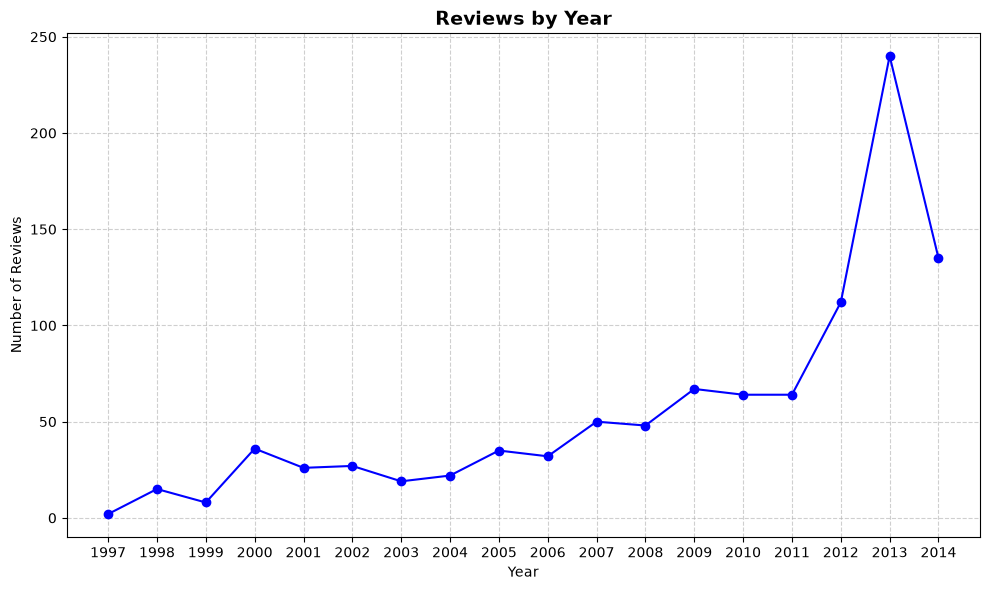

In [32]:
def convert_to_datetime(df: pd.DataFrame) -> pd.Series:
    return pd.to_datetime(df["unixReviewTime"], unit="s")

def get_yearly_counts(review_datetime: pd.Series) -> pd.Series:
    return review_datetime.dt.year.value_counts().sort_index()

def print_year_range(yearly_counts: pd.Series) -> None:
    print(f"Year range: {yearly_counts.index.min()} - {yearly_counts.index.max()}")

def print_reviews_by_year(yearly_counts: pd.Series, total_reviews: int) -> None:
    print("\nReviews by year:")
    print("-" * 50)
    for year, count in yearly_counts.items():
        percentage = count / total_reviews * 100
        print(
            f"{year}: "
            f"{count:>6,} reviews "
            f"({percentage:>6.2f}%)"
        )

def print_peak_year(yearly_counts: pd.Series) -> None:
    max_year = yearly_counts.idxmax()
    max_count = yearly_counts.max()
    print("\nPeak year:")
    print(f"  {max_year}: {max_count:,} reviews")

def plot_reviews_by_year(df: pd.DataFrame, start_year: int = None, end_year: int = None) -> None:
    review_datetime = pd.to_datetime(df["unixReviewTime"], unit="s")
    yearly_counts = review_datetime.dt.year.value_counts().sort_index()

    if start_year is not None:
        yearly_counts = yearly_counts[yearly_counts.index >= start_year]
    if end_year is not None:
        yearly_counts = yearly_counts[yearly_counts.index <= end_year]

    plt.figure(figsize=(10, 6))
    plt.plot(yearly_counts.index, yearly_counts.values, marker="o", linestyle="-", color="b")

    plt.title("Reviews by Year", fontsize=14, fontweight="bold")
    plt.xlabel("Year")
    plt.ylabel("Number of Reviews")
    plt.grid(True, linestyle="--", alpha=0.6)

    plt.xticks(yearly_counts.index)

    plt.tight_layout()
    plt.show()


    
def analyze_review_trend(df: pd.DataFrame) -> None:
    print("\n" + "=" * 70)
    print("REVIEW TREND BY YEAR")
    print("=" * 70)
    review_datetime = convert_to_datetime(df)
    yearly_counts = get_yearly_counts(review_datetime)
    print_year_range(yearly_counts)
    print_reviews_by_year(yearly_counts, len(df))
    print_peak_year(yearly_counts)
    plot_reviews_by_year(df, start_year=yearly_counts.index.min(), end_year=yearly_counts.index.max())

    print("=" * 70)

analyze_review_trend(dataset.ratings)